### 实验前的环境准备

这一格不是正式建模代码，而是实验开始前的“环境体检”。

为什么要先运行它？

1. 同一份 notebook 换一台电脑、换一个 Python 环境后，常见问题不是算法写错，而是缺少库。
2. 如果一开始不先检查，后面往往会在 `import`、画图、读文件或训练模型时突然报错，初学者很难判断问题到底出在代码还是环境。
3. 现在这一格已经升级为“先检查、再自动安装”，目的就是把环境问题尽量提前解决。

运行后你会看到几类信息：

1. 当前 notebook 实际使用的是哪个 Python 解释器。
2. 已经检测到哪些核心库。
3. 如果有缺失库，系统会尝试自动安装。
4. 如果安装完成后仍未生效，通常只需要重启内核，再从第 1 格重新运行。

可以把这一格理解成：正式做实验前，先把工具箱点一遍，缺什么先补什么。这样后面的每一步更容易顺利完成，也更符合真实开发中的工作流程。

In [1]:
import importlib
import subprocess
import sys

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'plotly': 'plotly',
    'nbformat': 'nbformat',
    'tqdm': 'tqdm',
    'imblearn': 'imbalanced-learn',
}

note_lines = [
    '说明：本教程读取 csv 文件，不需要额外安装 Excel 读取库。',
    '说明：本教程会在训练集上使用 SMOTE 处理类别不平衡，因此需要 imbalanced-learn。',
    '说明：本教程使用 Plotly 在 notebook 中显示三维图，因此建议同时具备 nbformat。',
]


def is_module_available(module_name):
    return importlib.util.find_spec(module_name) is not None


installed_modules = []
missing_packages = []
for module_name, package_name in required_packages.items():
    if is_module_available(module_name):
        installed_modules.append(module_name)
    else:
        missing_packages.append(package_name)

print('当前 Python 解释器:', sys.executable)
print('已检测到的模块:', ', '.join(installed_modules) if installed_modules else '无')

if missing_packages:
    print('\n检测到缺失依赖，开始自动安装:')
    print('pip install ' + ' '.join(missing_packages))
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
        importlib.invalidate_caches()
        still_missing = [
            package_name
            for module_name, package_name in required_packages.items()
            if not is_module_available(module_name)
        ]
        if still_missing:
            print('\n以下依赖安装后仍未检测到，请重启内核后重试:')
            print(', '.join(still_missing))
        else:
            print('\n依赖已自动安装完成，可以继续运行本教程。')
    except subprocess.CalledProcessError as error:
        print(f'\n自动安装失败，返回码: {error.returncode}')
        print('请手动执行:')
        print('pip install ' + ' '.join(missing_packages))
else:
    print('\n依赖检查通过，可以继续运行本教程。')

for note in note_lines:
    print(note)

print('如果你已经安装过，但这里仍显示缺失，通常是因为当前 notebook 内核和安装库使用的 Python 环境不是同一个。')
print('如果刚完成自动安装，后续单元格仍报导入错误，重启内核后再从头运行一次。')

当前 Python 解释器: g:\Miniconda\python.exe
已检测到的模块: numpy, torch, matplotlib, tqdm

检测到缺失依赖，开始自动安装:
pip install pandas scikit-learn plotly nbformat imbalanced-learn

依赖已自动安装完成，可以继续运行本教程。
说明：本教程读取 csv 文件，不需要额外安装 Excel 读取库。
说明：本教程会在训练集上使用 SMOTE 处理类别不平衡，因此需要 imbalanced-learn。
说明：本教程使用 Plotly 在 notebook 中显示三维图，因此建议同时具备 nbformat。
如果你已经安装过，但这里仍显示缺失，通常是因为当前 notebook 内核和安装库使用的 Python 环境不是同一个。
如果刚完成自动安装，后续单元格仍报导入错误，重启内核后再从头运行一次。


### 医学公开数据集分类实践

本实验将原来的金融欺诈分类案例替换为公开、经典、适合初学者的医学二分类任务，同时把操作步骤整理为与常规欺诈分类教程一致的节奏：先读取本地文件，再检查原始表、完成数据清洗与特征工程，最后再进行 PyTorch 分类建模与结果分析。

- 数据集：Pima Indians Diabetes Dataset（公开医学分类数据集）
- 本地文件：medical_diabetes_classification.csv
- 任务：根据体检和代谢指标判断样本是否属于糖尿病高风险类别
- 数据集简介：该数据集来源于经典的糖尿病风险预测研究，字段均为结构化数值特征，适合初学者做二分类建模
- 优点：公开可得、样本量适中、字段复杂度与原实验接近、与常规欺诈分类共享相同建模框架，便于横向比较不同任务

#### 本实验建议关注 4 个问题

1. 哪些字段出现 0 其实不合理，为什么可以视作异常值？
2. 为什么要观察类别分布，而不是只看总样本数？
3. 为什么预测输出是概率，而不是直接输出“是/否”？
4. 如果修改阈值、学习率或训练轮数，分类结果会怎样变化？

### 开始前先建立分类概念框架

为了让医疗版和常规版的分类教程能直接对照，先把这两个实验共享的几个核心概念说清楚：

1. 分类任务预测的不是连续数值，而是“属于某一类的概率”，本章里分别是糖尿病高风险和欺诈交易风险。
2. `Sigmoid()` 会把模型输出压到 0 到 1 之间，所以我们可以把结果解释成“像正类的程度”。
3. 阈值决定“多大概率才判成正类”，阈值变低通常召回率更高，但误报也更容易增加。
4. 分类模型常用 `BCELoss()` 这类损失函数来衡量概率预测与真实标签的差距，模型会据此做反向更新。
5. `accuracy` 不是唯一指标，还要结合混淆矩阵、召回率和误判样本一起看；`learning_rate`、`epochs`、`threshold` 都会改变最终表现。

先有这套概念框架，后面再看代码，学生就更容易理解“为什么同一套 MLP，在不同场景里关注的评价重点不同”。

### 第一步：准备实验工具

这一格是分类实验的“工具箱准备”区。

这里导入的库分别承担不同角色：

1. `pandas`、`numpy`：读表、整理数据、做基础计算。
2. `torch`：搭建和训练神经网络。
3. `sklearn`：做标准化、划分训练集测试集、计算分类指标。
4. `matplotlib`、`plotly`：把分类结果和样本分布画出来。
5. `tqdm`：显示训练进度。

零基础时不用急着记住全部语法，先知道“后面每一步都在调用这里准备好的工具”就够了。

In [2]:
# 引入必要的库
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from matplotlib import font_manager
import plotly.express as px
import plotly.io as pio
from tqdm import trange

def configure_matplotlib_for_cjk():
    """
    配置Matplotlib以正确显示中日韩(CJK)字符
    该函数会尝试设置一个可用的中文字体，以确保图表中的中文显示正常
    """
    preferred_fonts = [
        "PingFang SC",
        "Hiragino Sans GB",
        "Heiti SC",
        "STHeiti",
        "Songti SC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "WenQuanYi Zen Hei",
        "DejaVu Sans",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False

configure_matplotlib_for_cjk()
pio.renderers.default = "plotly_mimetype"

### 第二步：认识原始数据

分类任务里，很多误解都来自“没看懂原始表就在建模”。

所以这里要先观察：

1. 总共有多少样本、多少字段？
2. 目标列是哪一列？
3. 类别是否平衡？
4. 有没有明显异常值或缺失值？

可以把这一步理解成“医生先看体检单，再决定下一步分析”，而不是直接跳到最后结论。

In [3]:
# 从本地 CSV 文件读取公开医学分类数据集，并先检查原始表结构
data = pd.read_csv("medical_diabetes_classification.csv")

print("数据集名称: Pima Indians Diabetes Dataset")
print("任务类型: 医学二分类")
print("原始样本数, 原始字段数:", data.shape)
print("\n原始字段信息:")
print(data.info())
print("\n原始缺失值统计:")
print(data.isnull().sum())
print("\n原始数据前 5 行:")
print(data.head())

print("\n原始类别分布:")
print(data["Outcome"].value_counts())

数据集名称: Pima Indians Diabetes Dataset
任务类型: 医学二分类
原始样本数, 原始字段数: (768, 9)

原始字段信息:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

原始缺失值统计:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI  

### 原始特征与补充特征含义

这一页的作用是先把“体检表上的每一列到底表示什么”讲明白，再进入异常值处理和特征工程。学生只有理解了字段含义，才更容易接受为什么某些 0 值不合理、为什么要继续构造分组特征。

**原始特征含义：**

1. `Pregnancies`：怀孕次数，用于描述既往妊娠经历。
2. `Glucose`：葡萄糖浓度，是糖尿病风险判断中的关键指标。
3. `BloodPressure`：舒张压，反映血压状况。
4. `SkinThickness`：皮褶厚度，可间接反映脂肪分布情况。
5. `Insulin`：胰岛素水平，与血糖调节能力相关。
6. `BMI`：身体质量指数，反映体重与身高的关系。
7. `DiabetesPedigreeFunction`：家族遗传风险指数。
8. `Age`：年龄。
9. `Outcome`：是否患糖尿病，是本任务要判断的标签。

**补充特征含义：**

1. `age_group`：年龄分组，把连续年龄转成更直观的阶段区间。
2. `bmi_level`：BMI 分层，用“偏低、正常、超重、肥胖”表达体型状态。
3. `glucose_level`：血糖水平分组，把原始数值整理成“正常、偏高、高风险”等更易解释的层次。

这些补充特征的意义，不是替代原始数值，而是把连续变化重新组织成更容易让模型和学生一起理解的医学区间。

### 第三步：清洗异常值

这里最关键的思想是：不是所有表格里的数字都能直接相信。

例如在这个医学数据里，有些字段出现 0 并不合理。不是说 0 永远错误，而是这些体征长期为 0 在现实中通常不成立，所以更像“缺失值伪装成了 0”。

因此这一步要做的事是：

1. 识别可疑的异常零值。
2. 把它们先转成缺失值。
3. 再用中位数补上，让数据恢复到更合理的状态。

可以把它理解成：先把测量表里的明显异常记录修正一下，再交给模型学习。

In [4]:
# 数据清洗：处理重复值、异常零值，并观察清洗前后的变化
data = data.drop_duplicates().copy()

columns_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
invalid_zero_counts = {column: int((data[column] == 0).sum()) for column in columns_with_invalid_zero}
print("异常零值统计:")
print(invalid_zero_counts)

for column in columns_with_invalid_zero:
    data[column] = data[column].replace(0, np.nan)
    data[column] = data[column].fillna(data[column].median())

print("\n清洗后缺失值统计:")
print(data.isnull().sum())
print("\n清洗后数值字段描述统计:")
print(data.describe().round(2))
print("\n教学提示：")
print("1. 这里把 0 当成异常值，不是因为 0 一定错误，而是因为这些体征通常不可能长期为 0。")
print("2. 中位数填补比均值更稳健，不容易被极端值拉偏。")
print("3. 这一步的目标不是追求复杂，而是让输入数据更接近真实可用状态。")

异常零值统计:
{'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'Insulin': 374, 'BMI': 11}

清洗后缺失值统计:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

清洗后数值字段描述统计:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   121.66          72.39          29.11   140.67   32.46   
std           3.37    30.44          12.10           8.79    86.38    6.88   
min           0.00    44.00          24.00           7.00    14.00   18.20   
25%           1.00    99.75          64.00          25.00   121.50   27.50   
50%           3.00   117.00          72.00          29.00   125.00   32.30   
75%           6.00   140.25          80.00          3

### 第四步：构造衍生特征，完成编码、标准化、SMOTE 与张量化

这一格和常规欺诈分类教程保持同样的操作目的，都是把原始记录一步步整理成神经网络能够学习的训练输入。

1. **构造衍生特征**：
   - 原始特征可能无法充分捕捉数据中的模式和关系。
   - 通过 BMI 分层、年龄分组、血糖风险分组等方式，可以把医学区间信息表达得更清楚。

2. **编码（Encoding）**：
   - 分组后的类别特征需要转换为数值形式。
   - 这里使用独热编码，把“属于哪个区间”变成模型可计算的数字列。

3. **标准化（Standardization）**：
   - 不同特征的量纲和取值范围差异很大。
   - 标准化可以将所有特征缩放到相似尺度，让网络训练更稳定。

4. **SMOTE 重采样（Class Balancing）**：
   - 医学分类里常见问题是正负样本数量不均衡。
   - SMOTE 会在训练集中为少数类合成新样本，帮助模型更充分地学习高风险样本模式。
   - 注意：SMOTE 只能用于训练集，不能用于测试集。

5. **张量化（Tensorization）**：
   - PyTorch 使用张量作为基本数据结构。
   - 把处理后的数组转换成张量后，模型才能进行前向计算、反向传播和参数更新。

**总结**：这一格不只是“整理数据格式”，而是在把医学体检信息一步步转换成更适合分类模型学习的训练输入。

In [5]:
# 构造衍生特征，完成编码、标准化、SMOTE 重采样与张量化
from importlib import import_module

smote_sampler_cls = getattr(import_module("imblearn.over_sampling"), "SMOTE")

data_model = data.copy()
data_model["age_group"] = pd.cut(
    data_model["Age"], bins=[20, 30, 40, 50, 100], labels=["21-30", "31-40", "41-50", "50+"], include_lowest=True
)
data_model["bmi_level"] = pd.cut(
    data_model["BMI"], bins=[0, 18.5, 24, 28, 100], labels=["偏低", "正常", "超重", "肥胖"]
)
data_model["glucose_level"] = pd.cut(
    data_model["Glucose"], bins=[0, 100, 126, 300], labels=["正常", "偏高", "高风险"]
)

data_model = pd.get_dummies(
    data_model, columns=["age_group", "bmi_level", "glucose_level"], drop_first=True
)

X = data_model.drop("Outcome", axis=1).astype(float)
y = data_model["Outcome"].values

print("建模字段数:", X.shape[1])
print("\n前 5 行特征:")
print(X.head())
print("\n原始类别分布:")
print(pd.Series(y).value_counts().sort_index())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n训练集类别分布（SMOTE 前）:")
print(pd.Series(y_train).value_counts().sort_index())
print("测试集类别分布:")
print(pd.Series(y_test).value_counts().sort_index())

smote_sampler = smote_sampler_cls(random_state=42)
X_train_resampled, y_train_resampled = smote_sampler.fit_resample(X_train, y_train)

print("\n训练集类别分布（SMOTE 后）:")
print(pd.Series(y_train_resampled).value_counts().sort_index())
print("\n教学提示：")
print("1. SMOTE 只作用在训练集，不能对测试集做重采样。")
print("2. 这样做的目标是让模型在训练时看到更均衡的正负样本。")
print("3. 测试集保持原始分布，才能更真实地检验模型泛化效果。")

X_train_tensor = torch.FloatTensor(X_train_resampled)
y_train_tensor = torch.FloatTensor(y_train_resampled)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

建模字段数: 16

前 5 行特征:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  age_group_31-40  age_group_41-50  \
0                     0.627  50.0              0.0              1.0   
1                     0.351  31.0              1.0              0.0   
2                     0.672  32.0              1.0              0.0   
3                     0.167  21.0              0.0              0.0   
4                     2.288  33.0              1.0              0.0   

   age_group_50+  bmi_level_正常  bmi_level_超重  bmi_level_肥胖  glucose_level_偏高  \
0            0.0           0.0          

### 为什么这里要使用 SMOTE，而前面的回归任务不用？

这一页特别容易混淆，所以要单独说明。

1. **SMOTE 只用于分类任务**：
   - 因为分类任务有“类别数目不均衡”的问题，例如糖尿病样本比非糖尿病样本少。
   - 如果不处理，模型可能只学会优先预测多数类，看起来准确率不低，但对少数类识别很差。

2. **回归任务通常不用 SMOTE**：
   - 回归任务预测的是连续数值，不存在“哪一类样本太少”的同类问题。
   - 医疗费用预测关注的是数值误差大小，而不是类别平衡，因此不适合直接套用 SMOTE 这种分类重采样方法。

3. **为什么只能对训练集做 SMOTE**：
   - 训练集是给模型学习用的，可以适当重采样帮助它看见更多少数类模式。
   - 测试集必须保持原始分布，否则评估结果会失真，看不出模型在真实数据上的表现。

4. **要提醒学生的一点**：
   - SMOTE 不是“凭空制造真实病人数据”，而是一种教学和建模中常见的少数类增强方法。
   - 它的作用是帮助模型更公平地学习两类样本，而不是替代真实医学数据采集。

可以把这一步理解成：在训练阶段，给模型补充一些“少数类练习题”，避免它只会做多数类那一类题。

#### 特征降维可视化

 > 先把高维特征压缩到三维空间，观察不同类别样本在低维空间里的分布。

 > 现在改为三维交互式散点图，你可以在 notebook 输出中直接旋转、缩放和悬停查看不同样本。

 > 如果两类样本在三维投影图上仍大面积重叠，说明后续可以继续思考更有判别力的特征工程。

In [6]:
# 用 PCA 把多维特征压缩到三维空间，观察两类样本分布
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    '主成分1': X_pca[:, 0],
    '主成分2': X_pca[:, 1],
    '主成分3': X_pca[:, 2],
    '类别': np.where(y == 1, '糖尿病', '非糖尿病'),
    '血糖值': data['Glucose'],
    'BMI': data['BMI'].round(2),
    '年龄': data['Age'],
})

fig = px.scatter_3d(
    pca_df,
    x='主成分1',
    y='主成分2',
    z='主成分3',
    color='类别',
    hover_data=['血糖值', 'BMI', '年龄'],
    title='医学分类任务：特征降维后的三维交互分布',
    opacity=0.7,
    color_discrete_map={'非糖尿病': '#4c956c', '糖尿病': '#d1495b'},
 )
fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()

explained_ratio = pca.explained_variance_ratio_
print('前三个主成分的方差解释率:', np.round(explained_ratio, 4))
print('累计解释率:', round(float(explained_ratio.sum()), 4)) 
print('教学提示：你可以旋转图形，观察糖尿病高风险样本是否在三维空间里形成相对聚集区域。')

前三个主成分的方差解释率: [0.2223 0.1475 0.1121]
累计解释率: 0.4819
教学提示：你可以旋转图形，观察糖尿病高风险样本是否在三维空间里形成相对聚集区域。


In [7]:
# 学生可在这里修改训练参数，再重新运行后续单元
student_config = {
    "hidden_dims": [32, 16],
    "learning_rate": 0.001,
    "epochs": 200,
    "threshold": 0.5,
}

print("当前实验参数:", student_config)
print("你可以尝试修改 hidden_dims、learning_rate、epochs、threshold，然后重新运行后面的训练与评估单元。")
print("说明：这里的默认结构设置与原始欺诈分类教程保持一致，便于横向比较任务差异。")

当前实验参数: {'hidden_dims': [32, 16], 'learning_rate': 0.001, 'epochs': 200, 'threshold': 0.5}
你可以尝试修改 hidden_dims、learning_rate、epochs、threshold，然后重新运行后面的训练与评估单元。
说明：这里的默认结构设置与原始欺诈分类教程保持一致，便于横向比较任务差异。


#### 可调参数实验

下面这个单元把一部分关键参数暴露出来，方便同学们边改边看结果。

当前默认结构与原始欺诈分类教程一致，建议优先尝试：
- 把 epochs 从 200 改成 100 或 400
- 把 learning_rate 从 0.001 改成 0.0005 或 0.002
- 把 threshold 从 0.5 改成 0.4 或 0.6

观察准确率、混淆矩阵和误判样本会怎样变化。

### 第五步：开始训练 MLP 分类模型

回归任务输出的是一个连续数值，而分类任务输出的通常是“属于某一类的概率”。

所以这里的 MLP 最后接了 `Sigmoid()`，目的是把输出压到 0 到 1 之间。这样我们就能把它解释成：

- 越接近 1，越像“高风险”
- 越接近 0，越像“低风险”

训练时模型会不断调整参数，让真正的糖尿病样本概率更高，让非糖尿病样本概率更低。

In [8]:
# 定义模型、损失函数、优化器
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

hidden_dims = student_config.get("hidden_dims", [32, 16])
learning_rate = student_config.get("learning_rate", 0.001)
num_epochs = student_config.get("epochs", 200)
threshold = student_config.get("threshold", 0.5)

model = MLP(X_train.shape[1], hidden_dims)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
# 训练模型
for epoch in trange(num_epochs, desc="Training Epochs"):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor).squeeze()
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

Training Epochs: 100%|██████████| 200/200 [00:00<00:00, 1698.52it/s]


### 第六步：查看分类结果

分类任务里，准确率当然重要，但它不是唯一指标。

这一格更值得重点观察的是：

1. 混淆矩阵：模型把谁判对了，把谁判错了？
2. 分类报告：不同类别的识别效果是否均衡？
3. 阈值：概率要大于多少，才算真正判成“糖尿病”？

可以把阈值理解成“报警线”。报警线调高或调低，都会改变误判和漏判的数量。

Accuracy: 0.7532

参数解释：
hidden_dims = [32, 16] 表示隐藏层结构
learning_rate = 0.001 表示每一步更新幅度
epochs = 200 表示训练轮数
threshold = 0.5 表示把概率转成最终类别时使用的阈值

Confusion Matrix:
[[75 25]
 [13 41]]

Classification Report:
              precision    recall  f1-score   support

        非糖尿病       0.85      0.75      0.80       100
         糖尿病       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



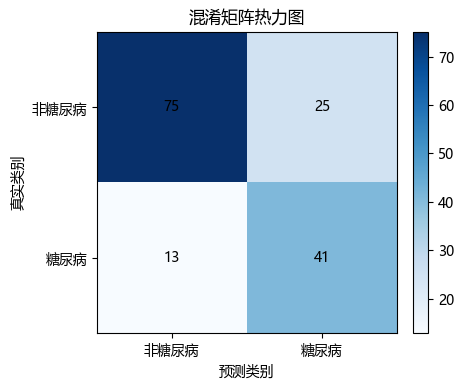

In [10]:
# 评估模型
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor).squeeze()
    predicted_classes = (test_outputs > threshold).float()
    confusion = confusion_matrix(y_test_tensor.numpy(), predicted_classes.numpy())
    accuracy = accuracy_score(y_test_tensor.numpy(), predicted_classes.numpy())
    print(f"Accuracy: {accuracy:.4f}")
    print("\n参数解释：")
    print(f"hidden_dims = {hidden_dims} 表示隐藏层结构")
    print(f"learning_rate = {learning_rate} 表示每一步更新幅度")
    print(f"epochs = {num_epochs} 表示训练轮数")
    print(f"threshold = {threshold} 表示把概率转成最终类别时使用的阈值")

    print("\nConfusion Matrix:")
    print(confusion)
    print("\nClassification Report:")
    print(classification_report(y_test_tensor.numpy(), predicted_classes.numpy(), target_names=["非糖尿病", "糖尿病"]))

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(confusion, cmap="Blues")
    ax.set_title("混淆矩阵热力图")
    ax.set_xlabel("预测类别")
    ax.set_ylabel("真实类别")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["非糖尿病", "糖尿病"])
    ax.set_yticklabels(["非糖尿病", "糖尿病"])

    for row_index in range(confusion.shape[0]):
        for column_index in range(confusion.shape[1]):
            ax.text(column_index, row_index, int(confusion[row_index, column_index]), ha="center", va="center", color="black")

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

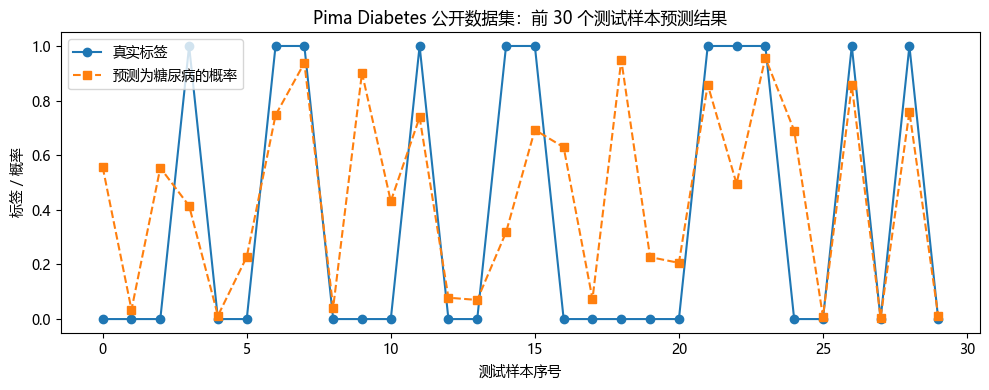

误判样本数: 38

示例误判样本：
真实标签: 非糖尿病
预测标签: 糖尿病
预测为糖尿病的概率: 0.5564550161361694

提示：该模型仅用于教学演示，不能直接替代医学筛查或临床诊断。


In [11]:
# 可视化预测结果与错误样本
%matplotlib inline
probabilities = test_outputs.numpy()
predictions_np = predicted_classes.numpy()
y_test_np = y_test_tensor.numpy()

plt.figure(figsize=(10, 4))
sample_count = 30
indices = np.arange(sample_count)
plt.plot(indices, y_test_np[:sample_count], "o-", label="真实标签")
plt.plot(indices, probabilities[:sample_count], "s--", label="预测为糖尿病的概率")
plt.title("Pima Diabetes 公开数据集：前 30 个测试样本预测结果")
plt.xlabel("测试样本序号")
plt.ylabel("标签 / 概率")
plt.legend()
plt.tight_layout()
plt.show()

wrong_indices = np.where(predictions_np != y_test_np)[0]
print("误判样本数:", len(wrong_indices))
if len(wrong_indices) > 0:
    first_wrong = int(wrong_indices[0])
    print("\n示例误判样本：")
    print("真实标签:", "糖尿病" if y_test_np[first_wrong] == 1 else "非糖尿病")
    print("预测标签:", "糖尿病" if predictions_np[first_wrong] == 1 else "非糖尿病")
    print("预测为糖尿病的概率:", float(probabilities[first_wrong]))

print("\n提示：该模型仅用于教学演示，不能直接替代医学筛查或临床诊断。")

### 第七步：分析概率区间误判

前面已经知道整体准确率，这一步进一步问的是：

- 模型是不是在某些概率区间特别容易出错？
- 接近 0.5 的样本，是不是更难判断？
- 阈值改变后，哪些区间最容易受影响？

这一步很像把考试总分拆开看：不是只看最后得了多少分，而是看“哪些题型最不稳定”。

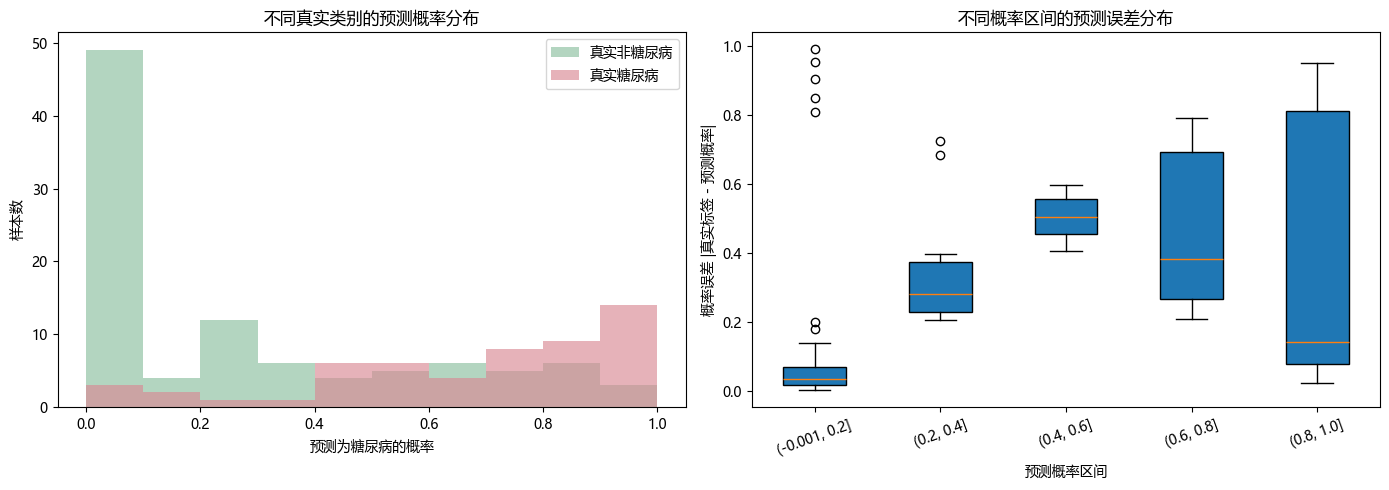

不同预测概率区间的误差统计：
            概率区间  样本数  平均概率误差  中位概率误差    误判率  最大概率误差
0  (-0.001, 0.2]   58   0.118   0.033  0.086   0.990
1     (0.2, 0.4]   20   0.323   0.280  0.100   0.724
2     (0.4, 0.6]   21   0.503   0.504  0.524   0.595
3     (0.6, 0.8]   23   0.480   0.383  0.478   0.790
4     (0.8, 1.0]   32   0.320   0.142  0.281   0.949

教学提示：如果某些区间误判率很高，说明模型在这些概率范围内还不够稳定，后续可结合阈值和特征工程继续改进。


In [12]:
# 概率区间误差分析：观察不同预测概率区间的误判分布
probability_error = np.abs(probabilities - y_test_np)
analysis_df = pd.DataFrame({
    '真实标签': y_test_np.astype(int),
    '预测标签': predictions_np.astype(int),
    '预测概率': probabilities,
    '概率误差': probability_error,
})

analysis_df['概率区间'] = pd.cut(
    analysis_df['预测概率'],
    bins=np.linspace(0, 1, 6),
    include_lowest=True,
    right=True,
 )

summary_rows = []
for interval_label, group in analysis_df.groupby('概率区间', observed=False):
    if len(group) == 0:
        continue
    summary_rows.append({
        '概率区间': interval_label,
        '样本数': len(group),
        '平均概率误差': round(group['概率误差'].mean(), 3),
        '中位概率误差': round(group['概率误差'].median(), 3),
        '误判率': round((group['预测标签'] != group['真实标签']).mean(), 3),
        '最大概率误差': round(group['概率误差'].max(), 3),
    })

error_summary = pd.DataFrame(summary_rows)

if error_summary.empty:
    print('当前测试集样本不足，未形成有效概率区间统计，请检查上游训练与预测结果。')
else:
    error_summary = error_summary.sort_values('概率区间').reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        probabilities[y_test_np == 0],
        bins=np.linspace(0, 1, 11),
        alpha=0.65,
        label='真实非糖尿病',
        color='#8bbf9f'
    )
    axes[0].hist(
        probabilities[y_test_np == 1],
        bins=np.linspace(0, 1, 11),
        alpha=0.65,
        label='真实糖尿病',
        color='#d98994'
    )
    axes[0].set_xlabel('预测为糖尿病的概率')
    axes[0].set_ylabel('样本数')
    axes[0].set_title('不同真实类别的预测概率分布')
    axes[0].legend()

    boxplot_data = [
        analysis_df.loc[analysis_df['概率区间'] == interval_label, '概率误差'].values
        for interval_label in error_summary['概率区间']
    ]
    boxplot_data = [arr for arr in boxplot_data if len(arr) > 0]

    if len(boxplot_data) > 0:
        axes[1].boxplot(boxplot_data, patch_artist=True)
        axes[1].set_xticks(range(1, len(error_summary['概率区间']) + 1))
        axes[1].set_xticklabels([str(label) for label in error_summary['概率区间']])
        axes[1].set_xlabel('预测概率区间')
        axes[1].set_ylabel('概率误差 |真实标签 - 预测概率|')
        axes[1].set_title('不同概率区间的预测误差分布')
        axes[1].tick_params(axis='x', rotation=20)
    else:
        axes[1].text(0.5, 0.5, '暂无可绘制箱线图数据', ha='center', va='center')
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

    print('不同预测概率区间的误差统计：')
    print(error_summary)
    print('\n教学提示：如果某些区间误判率很高，说明模型在这些概率范围内还不够稳定，后续可结合阈值和特征工程继续改进。')

#### 特征重要性反思与验证

> 这里用置乱测试来观察模型最依赖哪些特征。

> 每次只打乱一个特征，再比较准确率下降了多少；下降越明显，说明这个特征越重要。

基线 Accuracy: 0.7532

特征重要性验证结果（前 10 项）：
                          特征  打乱后准确率  准确率下降值
1                    Glucose  0.6039  0.1494
6   DiabetesPedigreeFunction  0.7078  0.0455
5                        BMI  0.7143  0.0390
8            age_group_31-40  0.7143  0.0390
0                Pregnancies  0.7273  0.0260
7                        Age  0.7403  0.0130
15         glucose_level_高风险  0.7403  0.0130
14          glucose_level_偏高  0.7403  0.0130
13              bmi_level_肥胖  0.7403  0.0130
4                    Insulin  0.7468  0.0065


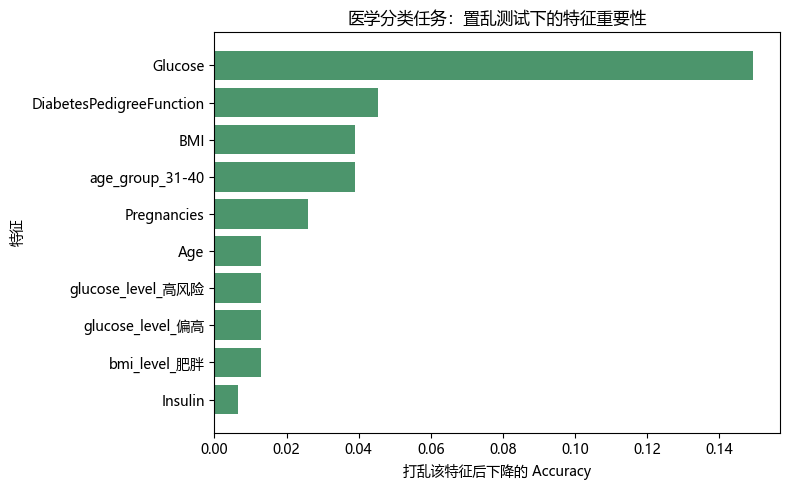

教学提示：准确率下降值越大，说明模型越依赖该特征。
注意：这只是教学版的重要性验证，不等于严格的因果解释。


In [13]:
# 用置乱测试验证分类任务中的特征重要性
baseline_accuracy = float(accuracy)
X_test_for_importance = X_test.copy()
importance_rows = []

for feature_index, feature_name in enumerate(X.columns):
    shuffled_X_test = X_test_for_importance.copy()
    np.random.seed(42)
    np.random.shuffle(shuffled_X_test[:, feature_index])
    shuffled_tensor = torch.FloatTensor(shuffled_X_test)

    with torch.no_grad():
        shuffled_probabilities = model(shuffled_tensor).squeeze().numpy()
        shuffled_predictions = (shuffled_probabilities > threshold).astype(float)

    shuffled_accuracy = accuracy_score(y_test, shuffled_predictions)
    importance_rows.append({
        '特征': feature_name,
        '打乱后准确率': round(float(shuffled_accuracy), 4),
        '准确率下降值': round(float(baseline_accuracy - shuffled_accuracy), 4),
    })

importance_df = pd.DataFrame(importance_rows).sort_values('准确率下降值', ascending=False)
top_importance = importance_df.head(10)
print('基线 Accuracy:', round(baseline_accuracy, 4))
print('\n特征重要性验证结果（前 10 项）：')
print(top_importance)

plt.figure(figsize=(8, 5))
plt.barh(top_importance['特征'], top_importance['准确率下降值'], color='#4c956c')
plt.gca().invert_yaxis()
plt.xlabel('打乱该特征后下降的 Accuracy')
plt.ylabel('特征')
plt.title('医学分类任务：置乱测试下的特征重要性')
plt.tight_layout()
plt.show()

print('教学提示：准确率下降值越大，说明模型越依赖该特征。')
print('注意：这只是教学版的重要性验证，不等于严格的因果解释。')

#### 结果反思与动手挑战

请同学们结合本次运行结果尝试回答下面几个问题：

1. 本次运行的 Accuracy 约为 0.74，这个结果是否足够说明模型已经“会判断糖尿病”了？为什么？
2. 从概率区间统计看，`0.4-0.6` 区间的误判率最高。为什么接近 0.5 的样本最不稳定？
3. 置乱测试里 `Glucose` 明显排在第一位，这说明了什么？为什么它的影响会明显高于大多数衍生分组特征？
4. 本次阈值实验里，`0.7` 的 Accuracy 高于默认的 `0.5`。这是否意味着课堂上就应该直接把阈值改成 0.7？
5. 如果把阈值从 0.5 改到 0.4，模型会更容易判成“糖尿病”还是“非糖尿病”？这对筛查场景意味着什么？
6. 在三维交互图中，两类样本是明显分开，还是仍有较大重叠？这和概率区间中的高误判区域能否对应起来？
7. 对医学筛查任务来说，漏判和误判哪个代价更大？你会优先优化哪个指标？

<details>
<summary>提示与参考答案</summary>

提示：把三维交互图、预测概率曲线、概率区间误差统计、阈值实验和置乱重要性结果一起看，重点关注“重叠区”“边界样本”“高误判区间”。

参考答案：
1. Accuracy 约 0.74 说明模型已经学到一部分规律，但还远不能当作可靠筛查工具，因为糖尿病类的 precision 和 recall 仍有明显提升空间。
2. `0.4-0.6` 区间最接近分类边界，说明模型对这些样本最不确定，所以误判率最高是合理现象。
3. `Glucose` 排在第一位，说明血糖信息是当前模型最核心的判断依据，这也符合医学常识。
4. 阈值 0.7 在这次运行中 Accuracy 更高，但它也会减少阳性预测数，因此不能只看 Accuracy 就决定阈值，还要结合漏判代价一起判断。
5. 把阈值从 0.5 调到 0.4 后，模型会更容易判成糖尿病，通常会提升召回，但误报也可能增加。
6. 如果三维图中两类样本仍大量重叠，就说明现有特征还不足以把边界完全拉开，这与中间概率区间误判率偏高是一致的。
7. 在筛查场景中，漏判高风险人群通常代价更大，因此往往会优先关注召回率而不是单一 Accuracy。
</details>

In [14]:
# 选做：观察不同阈值对分类结果的影响
threshold_candidates = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for threshold_candidate in threshold_candidates:
    predicted_candidate = (test_outputs > threshold_candidate).float()
    candidate_accuracy = accuracy_score(y_test_tensor.numpy(), predicted_candidate.numpy())
    threshold_results.append({
        "threshold": threshold_candidate,
        "accuracy": round(candidate_accuracy, 4),
        "positive_predictions": int(predicted_candidate.sum().item()),
    })

threshold_results_df = pd.DataFrame(threshold_results)
print(threshold_results_df)
print("\n思考：阈值越低，模型越容易把样本判成糖尿病；阈值越高，则越保守。")

   threshold  accuracy  positive_predictions
0        0.3    0.7338                    83
1        0.4    0.7662                    76
2        0.5    0.7532                    66
3        0.6    0.7468                    55
4        0.7    0.7597                    45

思考：阈值越低，模型越容易把样本判成糖尿病；阈值越高，则越保守。
